# CSE422 Project: Cricket Player Role Prediction

**Project type:** Supervised classification (Position Prediction) + Unsupervised learning (K-Means)

## Problem statement
Predict a cricket player's **role/position** — `Batsman`, `Bowler`, `Allrounder`, or `Wicketkeeper` — from biographical and playing-style attributes (batting style, bowling style, continent, gender, age).

**Structure:** dataset description → EDA → preprocessing (problem → solution) → train/test split → supervised model training (Logistic Regression, KNN, Decision Tree, Naive Bayes, Neural Network, Random Forest) → evaluation & comparison → cross-validation → K-Means clustering.

In [51]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Import Libraries

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score, auc
)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Load Dataset

In [53]:
players = pd.read_csv("/content/drive/MyDrive/CSE422_project/players_data_with_all_info.csv")
teams = pd.read_csv("/content/drive/MyDrive/CSE422_project/teams.csv")

print("Players dataset shape:", players.shape)
print("Teams dataset shape:", teams.shape)
players.head()

Players dataset shape: (17385, 16)
Teams dataset shape: (78, 7)


,id,firstname,lastname,fullname,image_path,dateofbirth,gender,battingstyle,bowlingstyle,position,updated_at,continent_id,continent_name,country_id,country_name,country_image_path
0,2,Ahmed,Shehzad,Ahmed Shehzad,https://cdn.sportmonks.com/images/cricket/play...,23-11-1991,m,right-hand-bat,legbreak,Batsman,2020-03-31T05:00:31.000000Z,2,Asia,52126,Pakistan,https://cdn.sportmonks.com/images/countries/pn...
1,3,Anwar,Ali,Anwar Ali,https://cdn.sportmonks.com/images/cricket/play...,25-11-1987,m,right-hand-bat,right-arm-fast-medium,Bowler,2020-12-14T18:58:56.000000Z,2,Asia,52126,Pakistan,https://cdn.sportmonks.com/images/countries/pn...
2,4,Sarfraz,Ahmed,Sarfraz Ahmed,https://cdn.sportmonks.com/images/cricket/play...,22-05-1987,m,right-hand-bat,right-arm-offbreak,Wicketkeeper,2020-04-07T08:51:02.000000Z,2,Asia,52126,Pakistan,https://cdn.sportmonks.com/images/countries/pn...
3,5,Azhar,Ali,Azhar Ali,https://cdn.sportmonks.com/images/cricket/play...,19-02-1985,m,right-hand-bat,legbreak,Batsman,2020-04-01T02:28:23.000000Z,2,Asia,52126,Pakistan,https://cdn.sportmonks.com/images/countries/pn...
4,6,Fakhar,Zaman,Fakhar Zaman,https://cdn.sportmonks.com/images/cricket/play...,10-04-1990,m,left-hand-bat,slow-left-arm-orthodox,Batsman,2020-04-02T02:22:22.000000Z,2,Asia,52126,Pakistan,https://cdn.sportmonks.com/images/countries/pn...


In [54]:
match_rate = players['country_id'].isin(teams['country_id']).mean()
print(f"Fraction of player rows with a matching country_id in teams.csv: {match_rate:.2%}")
print("\nteams.csv columns:", list(teams.columns))

Fraction of player rows with a matching country_id in teams.csv: 14.80%

teams.csv columns: ['id', 'name', 'code', 'image_path', 'country_id', 'national_team', 'updated_at']


**Conclusion:** Because of the low match rate and redundancy, **`teams.csv` is
excluded from modeling**

## 3. Dataset Overview

In [55]:
print("Shape (rows, columns):", players.shape)
print("\nColumn names:")
print(list(players.columns))

Shape (rows, columns): (17385, 16)

Column names:
['id', 'firstname', 'lastname', 'fullname', 'image_path', 'dateofbirth', 'gender', 'battingstyle', 'bowlingstyle', 'position', 'updated_at', 'continent_id', 'continent_name', 'country_id', 'country_name', 'country_image_path']


In [56]:
players.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17385 entries, 0 to 17384
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   id                  17385 non-null  int64 
 1   firstname           17385 non-null  object
 2   lastname            17385 non-null  object
 3   fullname            17385 non-null  object
 4   image_path          17385 non-null  object
 5   dateofbirth         17385 non-null  object
 6   gender              17385 non-null  object
 7   battingstyle        10063 non-null  object
 8   bowlingstyle        7883 non-null   object
 9   position            17385 non-null  object
 10  updated_at          17385 non-null  object
 11  continent_id        17385 non-null  int64 
 12  continent_name      17385 non-null  object
 13  country_id          17385 non-null  int64 
 14  country_name        17385 non-null  object
 15  country_image_path  17385 non-null  object
dtypes: int64(3), object(13

In [57]:
print("Missing values per column:")
print(players.isnull().sum())

Missing values per column:
id                       0
firstname                0
lastname                 0
fullname                 0
image_path               0
dateofbirth              0
gender                   0
battingstyle          7322
bowlingstyle          9502
position                 0
updated_at               0
continent_id             0
continent_name           0
country_id               0
country_name             0
country_image_path       0
dtype: int64


In [58]:
print("Fully duplicated rows:", players.duplicated().sum())
print("Duplicated 'id' values:", players['id'].duplicated().sum())

Fully duplicated rows: 0
Duplicated 'id' values: 0


In [59]:
print("Unique values in key categorical columns:")
for col in ['position', 'battingstyle', 'bowlingstyle', 'gender', 'continent_name']:
    print(f"\n--- {col} ---")
    print(players[col].value_counts(dropna=False))

Unique values in key categorical columns:

--- position ---
position
Bowler                 5711
Batsman                4915
Allrounder             4877
Wicketkeeper           1692
Middle Order Batter      54
Bowling Allrounder       49
Top Order Batter         49
Batting Allrounder       38
Name: count, dtype: int64

--- battingstyle ---
battingstyle
right-hand-bat    8300
NaN               7322
left-hand-bat     1763
Name: count, dtype: int64

--- bowlingstyle ---
bowlingstyle
NaN                        9502
right-arm-fast-medium      3913
right-arm-offbreak         1247
right-arm-fast              867
slow-left-arm-orthodox      713
left-arm-fast-medium        465
legbreak                    346
legbreak-googly             201
left-arm-fast               107
slow-right-arm-orthodox      22
left-arm-chinaman             2
Name: count, dtype: int64

--- gender ---
gender
m    16280
f     1105
Name: count, dtype: int64

--- continent_name ---
continent_name
Europe           8226
Asia  

## 4. Data Cleaning / Quality Analysis

### 4.1 The 25 unparseable `dateofbirth` values

In [60]:
dob_parsed_raw = pd.to_datetime(players['dateofbirth'], format='%d-%m-%Y', errors='coerce')
unparseable_mask = dob_parsed_raw.isna()
unparseable_rows = players.loc[unparseable_mask, ['id', 'fullname', 'dateofbirth', 'position']]
print(f"Number of unparseable dateofbirth values: {unparseable_mask.sum()}")
unparseable_rows

Number of unparseable dateofbirth values: 25


,id,fullname,dateofbirth,position
2629,6547,Abdul Rehman,0000-00-00,Allrounder
3691,9840,Imran Ali,0992-12-03,Bowler
9486,27572,Kumar Kumar Paudel,0200-09-02,Batsman
10950,32120,Vimal Marripeddi,0000-00-00,Allrounder
11139,32702,Suman Ghimire,0000-00-00,Batsman
11610,34229,Muzaifa Muhammad,0000-00-00,Bowler
11611,34232,Sarbjit Singh,0000-00-00,Batsman
11914,35165,Yasir Mohammad,0200-10-10,Batsman
14107,41846,Aritharan Thivakaran,0000-00-00,Batsman
14120,41888,Abhijai Mansingh,0000-00-00,Batsman


In [61]:
sentinel_null = unparseable_rows['dateofbirth'].eq('0000-00-00')
print(f"Pattern A — literal sentinel null '0000-00-00' (day=0, month=0, year=0000): "
      f"{sentinel_null.sum()} rows")
print(unparseable_rows.loc[sentinel_null, 'dateofbirth'].unique())

pattern_b = unparseable_rows.loc[~sentinel_null]
print(f"\nPattern B — implausible/corrupted 4-digit years: {len(pattern_b)} rows")
print(pattern_b[['dateofbirth']])

Pattern A — literal sentinel null '0000-00-00' (day=0, month=0, year=0000): 20 rows
['0000-00-00']

Pattern B — implausible/corrupted 4-digit years: 5 rows
      dateofbirth
3691   0992-12-03
9486   0200-09-02
11914  0200-10-10
17041  0200-01-01
17144  0199-01-17


### 4.2 The placeholder DOB pattern (~6,081 rows)


In [62]:
day_month = players['dateofbirth'].str.slice(0, 5)
year_str = players['dateofbirth'].str.slice(6, 10)

overall_jan1_rate = (day_month == '01-01').mean()
print(f"Overall share of rows with day-month '01-01': {overall_jan1_rate:.2%} "
      f"(expected under genuine random birthdates: ~{1/365:.2%})")

Overall share of rows with day-month '01-01': 37.04% (expected under genuine random birthdates: ~0.27%)


In [63]:

year_check = []
for y in sorted(year_str.dropna().unique()):
    if not y.isdigit() or y in ('0000', '0200', '0199', '0992'):
        continue
    total_y = (year_str == y).sum()
    jan1_y = ((year_str == y) & (day_month == '01-01')).sum()
    if total_y >= 50:
        year_check.append((y, total_y, jan1_y, jan1_y / total_y))

year_check_df = pd.DataFrame(year_check, columns=['year', 'total_players', 'jan1_count', 'jan1_rate'])
year_check_df.sort_values('year')

,year,total_players,jan1_count,jan1_rate
0,1976,53,1,0.018868
1,1977,65,1,0.015385
2,1978,86,0,0.000000
3,1979,111,2,0.018018
4,1980,130,6,0.046154
5,1981,157,3,0.019108
6,1982,212,1,0.004717
7,1983,227,4,0.017621
8,1984,280,7,0.025000
9,1985,296,9,0.030405


In [64]:
placeholder_mask = (day_month == '01-01') & (year_str.isin(['2000', '2001', '2002', '2003', '2004']))
print(f"Rows matching the placeholder-DOB rule: {placeholder_mask.sum()}")

players['is_dob_estimated'] = (unparseable_mask | placeholder_mask)
print(f"Total rows flagged as is_dob_estimated: {players['is_dob_estimated'].sum()} "
      f"({players['is_dob_estimated'].mean():.1%} of the dataset)")

Rows matching the placeholder-DOB rule: 6081
Total rows flagged as is_dob_estimated: 6106 (35.1% of the dataset)


### 4.3 Building the `age` feature


In [65]:
REFERENCE_DATE = pd.Timestamp('2024-01-01')
players['dob_parsed'] = dob_parsed_raw
players['age'] = (REFERENCE_DATE - players['dob_parsed']).dt.days / 365.25

print(players['age'].describe())
print(f"\nRows with missing age (from unparseable DOBs): {players['age'].isna().sum()}")

count    17360.000000
mean        28.148183
std          7.108758
min         14.291581
25%         22.997947
50%         24.928131
75%         32.339493
max         76.698152
Name: age, dtype: float64

Rows with missing age (from unparseable DOBs): 25


## 5. Target Transformation


In [66]:
print("Original position value counts:")
print(players['position'].value_counts())

merge_map = {
    'Middle Order Batter': 'Batsman',
    'Top Order Batter': 'Batsman',
    'Bowling Allrounder': 'Allrounder',
    'Batting Allrounder': 'Allrounder',
}
players['position_clean'] = players['position'].replace(merge_map)

print("\nMerged position value counts (final target: 'position_clean'):")
print(players['position_clean'].value_counts())

Original position value counts:
position
Bowler                 5711
Batsman                4915
Allrounder             4877
Wicketkeeper           1692
Middle Order Batter      54
Bowling Allrounder       49
Top Order Batter         49
Batting Allrounder       38
Name: count, dtype: int64

Merged position value counts (final target: 'position_clean'):
position_clean
Bowler          5711
Batsman         5018
Allrounder      4964
Wicketkeeper    1692
Name: count, dtype: int64


## 6. Exploratory Data Analysis

### 6.1 Target class distribution (imbalance check)

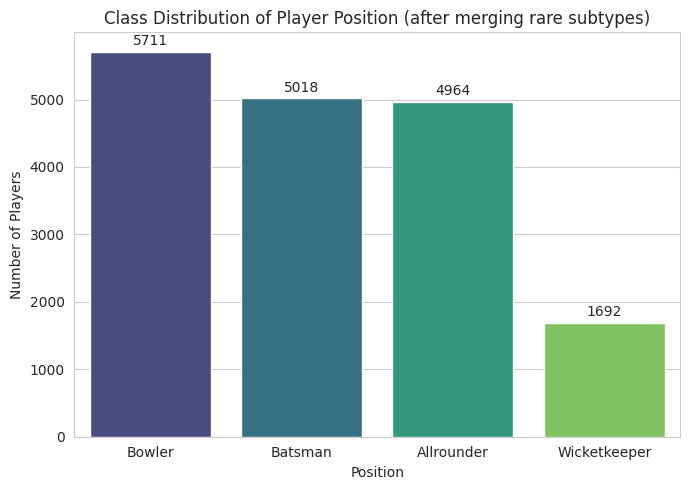

position_clean
Bowler          5711
Batsman         5018
Allrounder      4964
Wicketkeeper    1692
Name: count, dtype: int64

Imbalance ratio (largest / smallest class): 3.38


In [67]:
target_counts = players['position_clean'].value_counts()
plt.figure(figsize=(7, 5))
sns.barplot(x=target_counts.index, y=target_counts.values, hue=target_counts.index,
            palette='viridis', legend=False)
plt.title('Class Distribution of Player Position (after merging rare subtypes)')
plt.ylabel('Number of Players')
plt.xlabel('Position')
for i, v in enumerate(target_counts.values):
    plt.text(i, v + 100, str(v), ha='center')
plt.tight_layout()
plt.savefig('outputs_target_distribution.png', dpi=110)
plt.show()

print(target_counts)
print(f"\nImbalance ratio (largest / smallest class): {target_counts.max() / target_counts.min():.2f}")

**Finding:** the classes are **not balanced**.

### 6.2 Correlation heatmap



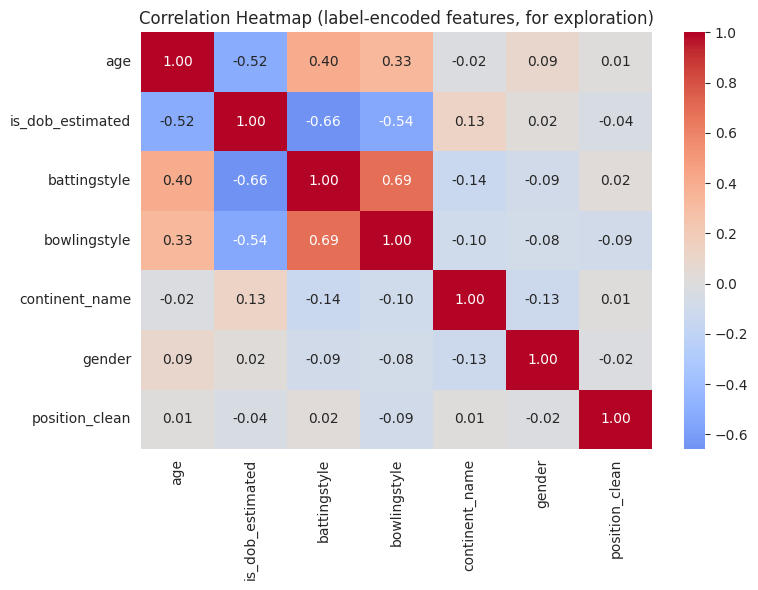

In [68]:
corr_df = players[['age', 'is_dob_estimated', 'battingstyle', 'bowlingstyle',
                    'continent_name', 'gender', 'position_clean']].copy()

for col in ['battingstyle', 'bowlingstyle', 'continent_name', 'gender', 'position_clean']:
    corr_df[col] = corr_df[col].fillna('Missing')
    corr_df[col] = LabelEncoder().fit_transform(corr_df[col].astype(str))

corr_df['is_dob_estimated'] = corr_df['is_dob_estimated'].astype(int)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap (label-encoded features, for exploration)')
plt.tight_layout()
plt.savefig('outputs_correlation_heatmap.png', dpi=110)
plt.show()

**What this heatmap shows and its limitations:** none of the input features shows a strong linear

### 6.3 Batting style vs. Position

<Figure size 800x500 with 0 Axes>

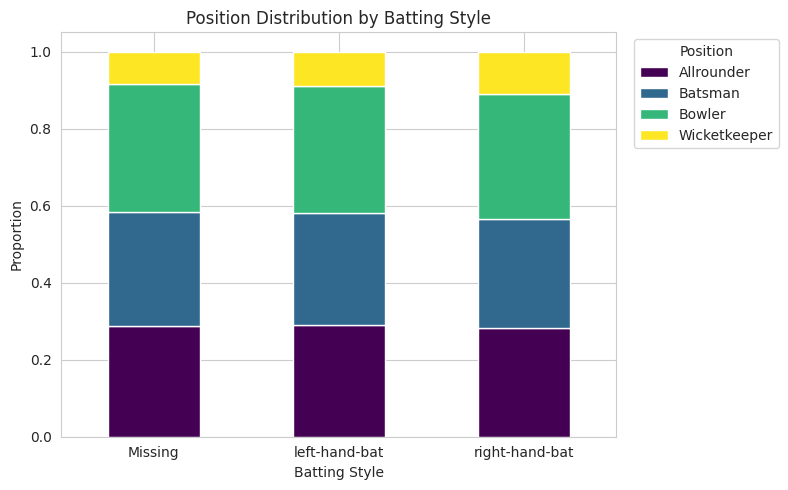

In [69]:
plt.figure(figsize=(8, 5))
ct = pd.crosstab(players['battingstyle'].fillna('Missing'), players['position_clean'], normalize='index')
ct.plot(kind='bar', stacked=True, colormap='viridis', figsize=(8, 5))
plt.title('Position Distribution by Batting Style')
plt.ylabel('Proportion')
plt.xlabel('Batting Style')
plt.xticks(rotation=0)
plt.legend(title='Position', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('outputs_battingstyle_vs_position.png', dpi=110)
plt.show()

### 6.4 Bowling style vs. Position

<Figure size 1000x600 with 0 Axes>

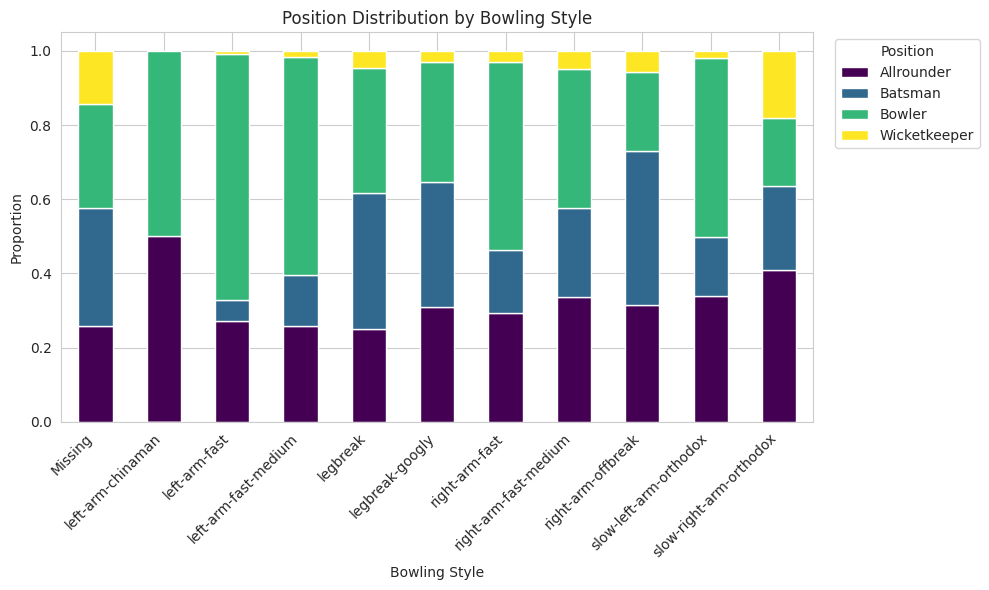

In [70]:
plt.figure(figsize=(10, 6))
ct2 = pd.crosstab(players['bowlingstyle'].fillna('Missing'), players['position_clean'], normalize='index')
ct2.plot(kind='bar', stacked=True, colormap='viridis', figsize=(10, 6))
plt.title('Position Distribution by Bowling Style')
plt.ylabel('Proportion')
plt.xlabel('Bowling Style')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Position', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('outputs_bowlingstyle_vs_position.png', dpi=110)
plt.show()

### 6.5 Continent vs. Position

<Figure size 900x500 with 0 Axes>

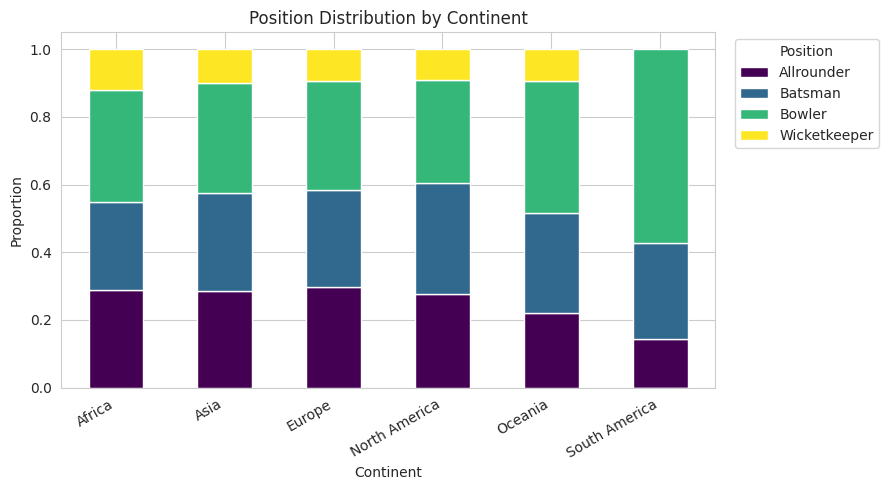

In [71]:
plt.figure(figsize=(9, 5))
ct3 = pd.crosstab(players['continent_name'], players['position_clean'], normalize='index')
ct3.plot(kind='bar', stacked=True, colormap='viridis', figsize=(9, 5))
plt.title('Position Distribution by Continent')
plt.ylabel('Proportion')
plt.xlabel('Continent')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Position', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('outputs_continent_vs_position.png', dpi=110)
plt.show()

### 6.6 Age distribution by Position

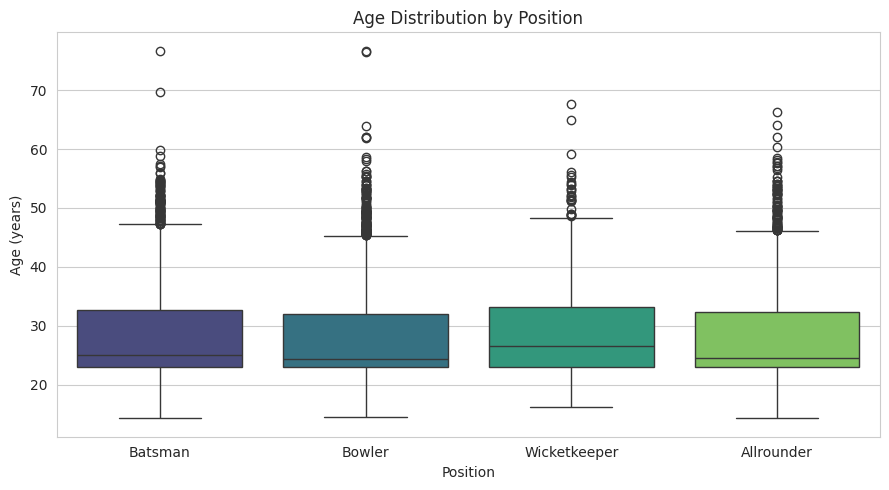

                 count       mean       std        min        25%        50%  \
position_clean                                                                 
Allrounder      4960.0  28.016961  6.983113  14.291581  22.997947  24.469541   
Batsman         5010.0  28.315133  7.208838  14.310746  22.997947  25.122519   
Bowler          5698.0  27.944203  7.077647  14.546201  22.997947  24.392882   
Wicketkeeper    1692.0  28.725440  7.242382  16.169747  22.997947  26.542094   

                      75%        max  
position_clean                        
Allrounder      32.271732  66.343600  
Batsman         32.707734  76.621492  
Bowler          31.934292  76.698152  
Wicketkeeper    33.215606  67.731691  


In [72]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=players, x='position_clean', y='age', hue='position_clean',
            palette='viridis', legend=False)
plt.title('Age Distribution by Position')
plt.xlabel('Position')
plt.ylabel('Age (years)')
plt.tight_layout()
plt.savefig('outputs_age_vs_position.png', dpi=110)
plt.show()

print(players.groupby('position_clean')['age'].describe())

### 6.7 Gender vs. Position

<Figure size 700x500 with 0 Axes>

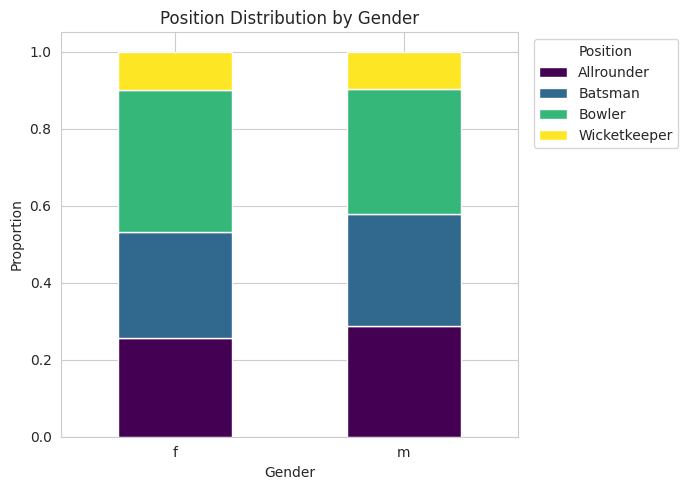

In [73]:
plt.figure(figsize=(7, 5))
ct4 = pd.crosstab(players['gender'], players['position_clean'], normalize='index')
ct4.plot(kind='bar', stacked=True, colormap='viridis', figsize=(7, 5))
plt.title('Position Distribution by Gender')
plt.ylabel('Proportion')
plt.xlabel('Gender')
plt.xticks(rotation=0)
plt.legend(title='Position', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('outputs_gender_vs_position.png', dpi=110)
plt.show()

**EDA summary:** Continent and age barely differ across positions, so they're weak predictors. Batting style and bowling style are the strongest predictors.

## 7. Feature Engineering


In [74]:
players['battingstyle_clean'] = players['battingstyle'].fillna('Missing')
players['bowlingstyle_clean'] = players['bowlingstyle'].fillna('Missing')

CAT_FEATURES = ['battingstyle_clean', 'bowlingstyle_clean', 'continent_name', 'gender']
NUM_FEATURES = ['age']
FLAG_FEATURES = ['is_dob_estimated']

model_df = players[CAT_FEATURES + NUM_FEATURES + FLAG_FEATURES + ['position_clean']].copy()
model_df = model_df.rename(columns={'position_clean': 'target'})
model_df.head()

,battingstyle_clean,bowlingstyle_clean,continent_name,gender,age,is_dob_estimated,target
0,right-hand-bat,legbreak,Asia,m,32.106776,False,Batsman
1,right-hand-bat,right-arm-fast-medium,Asia,m,36.101300,False,Bowler
2,right-hand-bat,right-arm-offbreak,Asia,m,36.613279,False,Wicketkeeper
3,right-hand-bat,legbreak,Asia,m,38.863792,False,Batsman
4,left-hand-bat,slow-left-arm-orthodox,Asia,m,33.727584,False,Batsman


## 8. Train/Test Split

In [75]:
X = model_df.drop(columns=['target'])
y = model_df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("\nTrain class proportions:")
print(y_train.value_counts(normalize=True))
print("\nTest class proportions:")
print(y_test.value_counts(normalize=True))

Train shape: (13908, 6)  Test shape: (3477, 6)

Train class proportions:
target
Bowler          0.328516
Batsman         0.288611
Allrounder      0.285519
Wicketkeeper    0.097354
Name: proportion, dtype: float64

Test class proportions:
target
Bowler          0.328444
Batsman         0.288755
Allrounder      0.285591
Wicketkeeper    0.097210
Name: proportion, dtype: float64


In [76]:
age_median_train = X_train['age'].median()
print(f"Median age computed from TRAINING set: {age_median_train:.2f} years")

X_train = X_train.copy()
X_test = X_test.copy()
X_train['age'] = X_train['age'].fillna(age_median_train)
X_test['age'] = X_test['age'].fillna(age_median_train)

Median age computed from TRAINING set: 24.85 years


## 9. Model Training



In [77]:
preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_FEATURES),
    ('num', StandardScaler(), NUM_FEATURES),
    ('flag', 'passthrough', FLAG_FEATURES),
])

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced',
                                               random_state=RANDOM_STATE),
    'KNN': KNeighborsClassifier(n_neighbors=15),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, class_weight='balanced',
                                             random_state=RANDOM_STATE),
    'Naive Bayes': GaussianNB(),
    'Neural Network (MLP)': MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=500,
                                           random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=12, class_weight='balanced',
                                             random_state=RANDOM_STATE),
}

CLASS_LABELS = sorted(y.unique())
print("Classes:", CLASS_LABELS)

fitted_pipelines = {}
for name, clf in models.items():
    pipe = Pipeline([('prep', preprocessor), ('clf', clf)])
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe
    print(f"Trained: {name}")

Classes: ['Allrounder', 'Batsman', 'Bowler', 'Wicketkeeper']
Trained: Logistic Regression
Trained: KNN
Trained: Decision Tree
Trained: Naive Bayes
Trained: Neural Network (MLP)
Trained: Random Forest


## 10. Model Evaluation


In [78]:
def evaluate_and_plot(name, pipe, X_test, y_test, class_labels):
    y_pred = pipe.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec_w = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec_w = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1_w = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    prec_m = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec_m = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1_m = f1_score(y_test, y_pred, average='macro', zero_division=0)

    roc_auc_macro = np.nan
    fpr_dict, tpr_dict, auc_dict = {}, {}, {}
    try:
        y_proba = pipe.predict_proba(X_test)
        y_test_bin = label_binarize(y_test, classes=class_labels)
        roc_auc_macro = roc_auc_score(y_test_bin, y_proba, average='macro', multi_class='ovr')
        for i, cls in enumerate(class_labels):
            fpr_dict[cls], tpr_dict[cls], _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
            auc_dict[cls] = auc(fpr_dict[cls], tpr_dict[cls])
    except Exception as e:
        print(f"  (ROC-AUC unavailable for {name}: {e})")

    print(f"\n===== {name} =====")
    print(f"Accuracy:          {acc:.4f}")
    print(f"Precision (macro): {prec_m:.4f}   Precision (weighted): {prec_w:.4f}")
    print(f"Recall (macro):    {rec_m:.4f}   Recall (weighted):    {rec_w:.4f}")
    print(f"F1 (macro):        {f1_m:.4f}   F1 (weighted):        {f1_w:.4f}")
    print(f"ROC-AUC (macro OvR): {roc_auc_macro:.4f}" if not np.isnan(roc_auc_macro) else "ROC-AUC: N/A")

    cm = confusion_matrix(y_test, y_pred, labels=class_labels)
    fig, axes = plt.subplots(1, 2 if fpr_dict else 1, figsize=(14, 5) if fpr_dict else (6, 5))
    ax_cm = axes[0] if fpr_dict else axes
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    disp.plot(ax=ax_cm, cmap='Blues', colorbar=False, xticks_rotation=30)
    ax_cm.set_title(f'{name} — Confusion Matrix')

    if fpr_dict:
        ax_roc = axes[1]
        for cls in class_labels:
            ax_roc.plot(fpr_dict[cls], tpr_dict[cls], label=f'{cls} (AUC={auc_dict[cls]:.2f})')
        ax_roc.plot([0, 1], [0, 1], 'k--', alpha=0.4)
        ax_roc.set_xlabel('False Positive Rate')
        ax_roc.set_ylabel('True Positive Rate')
        ax_roc.set_title(f'{name} — One-vs-Rest ROC Curves')
        ax_roc.legend(loc='lower right', fontsize=8)

    plt.tight_layout()
    safe_name = name.lower().replace(' ', '_').replace('(', '').replace(')', '')
    plt.savefig(f'outputs_eval_{safe_name}.png', dpi=110)
    plt.show()

    return {
        'Model': name, 'Accuracy': acc,
        'Precision (weighted)': prec_w, 'Recall (weighted)': rec_w, 'F1 (weighted)': f1_w,
        'Macro Precision': prec_m, 'Macro Recall': rec_m, 'Macro F1': f1_m,
        'ROC-AUC (macro OvR)': roc_auc_macro
    }


===== Logistic Regression =====
Accuracy:          0.3566
Precision (macro): 0.3637   Precision (weighted): 0.3878
Recall (macro):    0.3851   Recall (weighted):    0.3566
F1 (macro):        0.3430   F1 (weighted):        0.3439
ROC-AUC (macro OvR): 0.6458


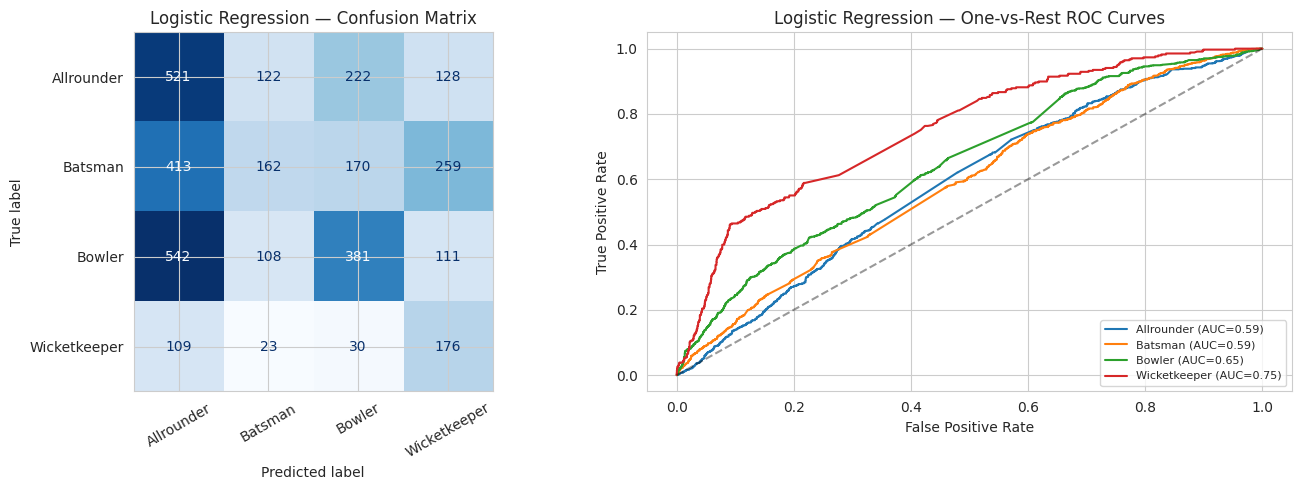


===== KNN =====
Accuracy:          0.3558
Precision (macro): 0.3628   Precision (weighted): 0.3604
Recall (macro):    0.3223   Recall (weighted):    0.3558
F1 (macro):        0.3302   F1 (weighted):        0.3525
ROC-AUC (macro OvR): 0.6145


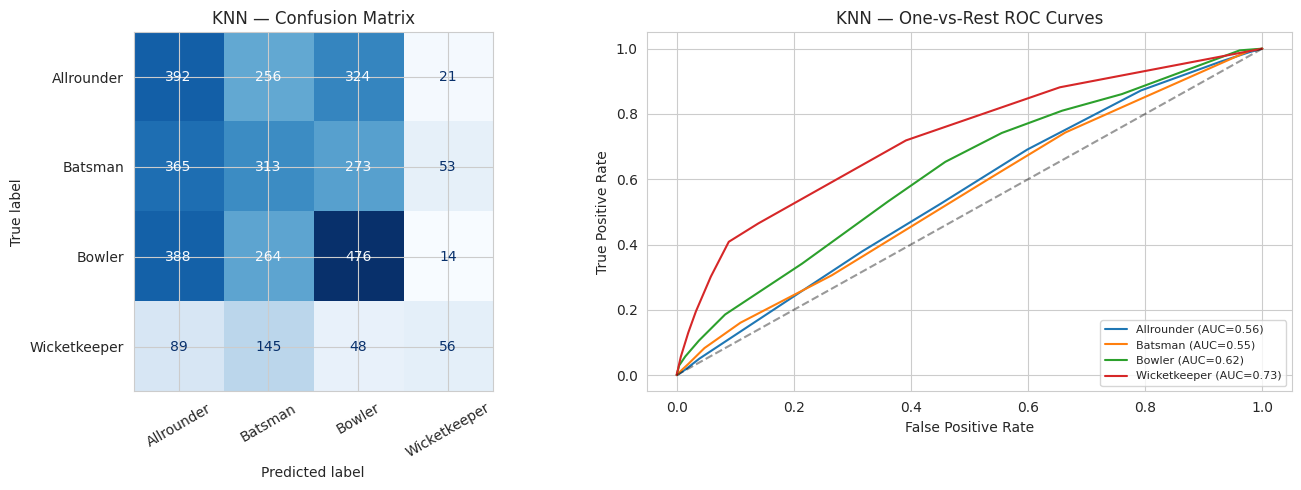


===== Decision Tree =====
Accuracy:          0.3592
Precision (macro): 0.3583   Precision (weighted): 0.3783
Recall (macro):    0.3705   Recall (weighted):    0.3592
F1 (macro):        0.3516   F1 (weighted):        0.3563
ROC-AUC (macro OvR): 0.6199


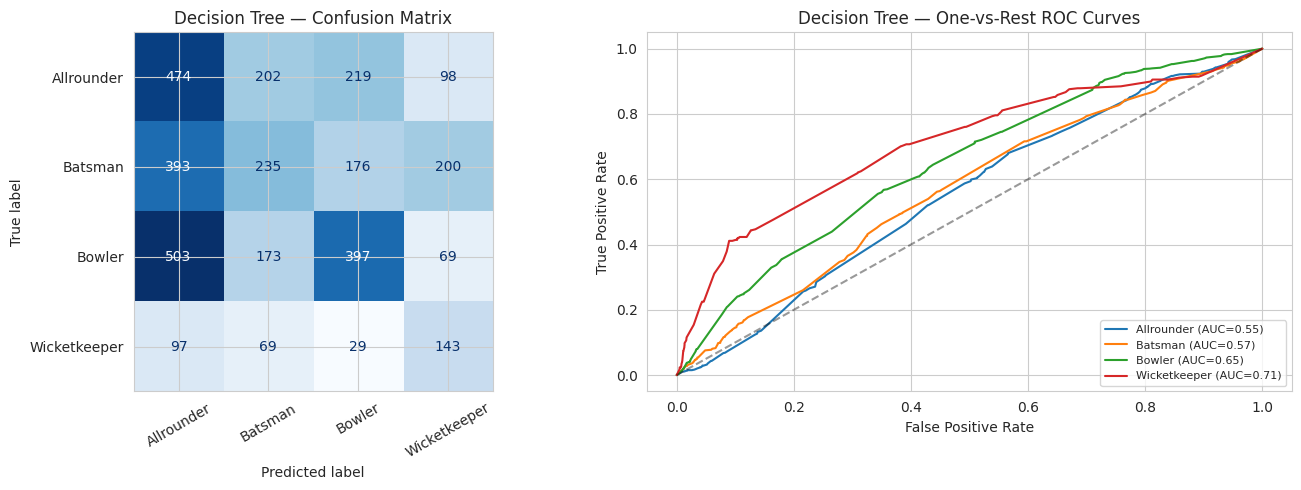


===== Naive Bayes =====
Accuracy:          0.1521
Precision (macro): 0.3477   Precision (weighted): 0.4030
Recall (macro):    0.2920   Recall (weighted):    0.1521
F1 (macro):        0.1303   F1 (weighted):        0.1158
ROC-AUC (macro OvR): 0.6060


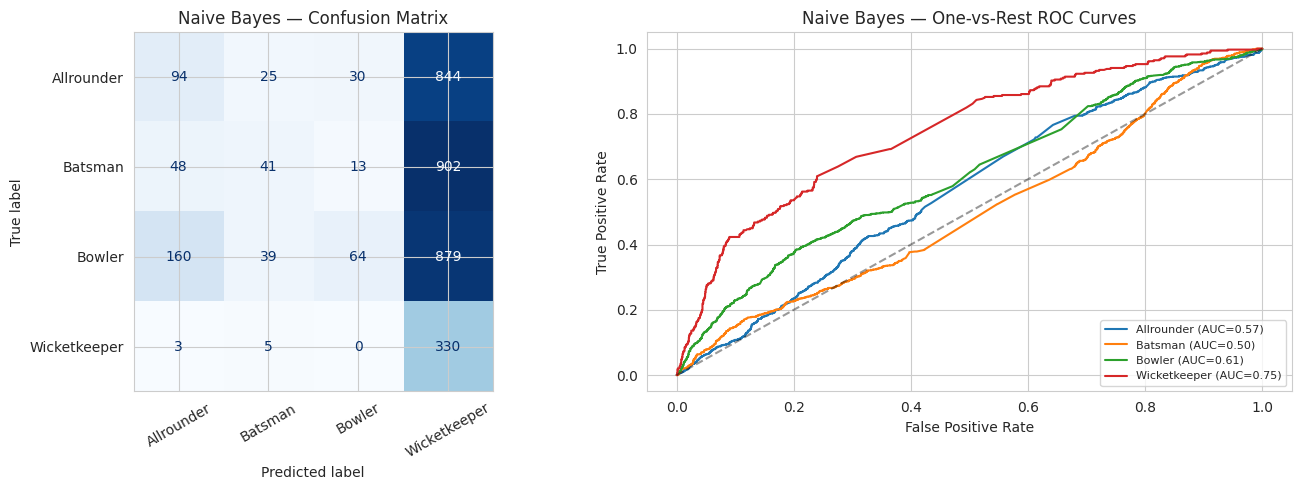


===== Neural Network (MLP) =====
Accuracy:          0.3831
Precision (macro): 0.3879   Precision (weighted): 0.3881
Recall (macro):    0.3327   Recall (weighted):    0.3831
F1 (macro):        0.3345   F1 (weighted):        0.3748
ROC-AUC (macro OvR): 0.6467


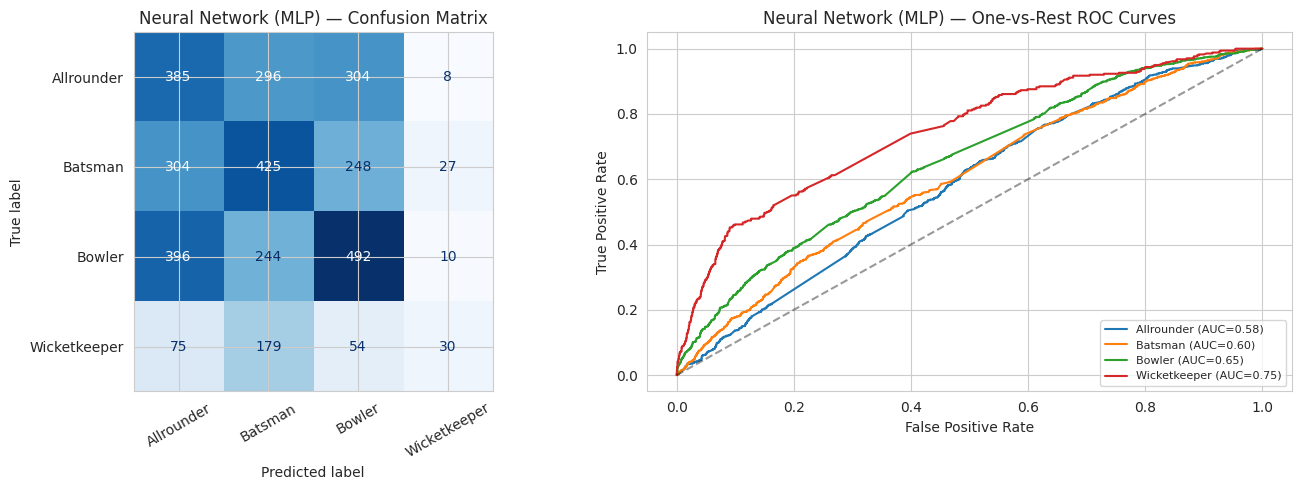


===== Random Forest =====
Accuracy:          0.3612
Precision (macro): 0.3567   Precision (weighted): 0.3728
Recall (macro):    0.3754   Recall (weighted):    0.3612
F1 (macro):        0.3563   F1 (weighted):        0.3586
ROC-AUC (macro OvR): 0.6413


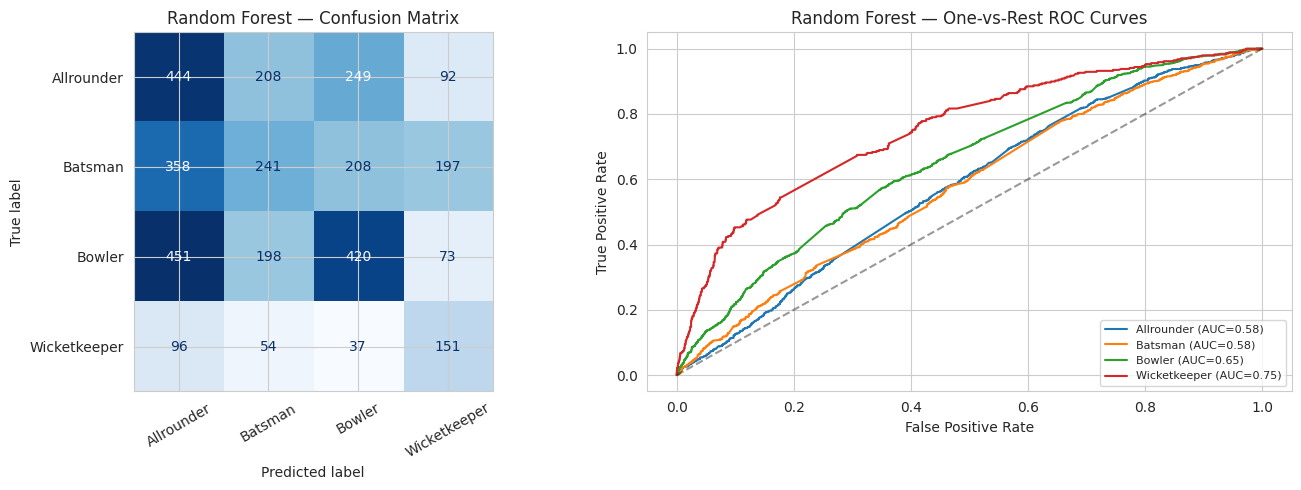

In [79]:
eval_results = []
for name, pipe in fitted_pipelines.items():
    res = evaluate_and_plot(name, pipe, X_test, y_test, CLASS_LABELS)
    eval_results.append(res)

## 11. Model Comparison

In [80]:
results_df = pd.DataFrame(eval_results).sort_values('Macro F1', ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision (weighted),Recall (weighted),F1 (weighted),Macro Precision,Macro Recall,Macro F1,ROC-AUC (macro OvR)
0,Random Forest,0.361231,0.372809,0.361231,0.358603,0.356698,0.375423,0.356324,0.641342
1,Decision Tree,0.359218,0.378292,0.359218,0.356331,0.358289,0.370529,0.351594,0.619885
2,Logistic Regression,0.356629,0.387816,0.356629,0.343852,0.363667,0.385091,0.343030,0.645784
3,Neural Network (MLP),0.383089,0.388116,0.383089,0.374807,0.387872,0.332650,0.334480,0.646675
4,KNN,0.355766,0.360404,0.355766,0.352500,0.362804,0.322252,0.330233,0.614534
5,Naive Bayes,0.152143,0.402953,0.152143,0.115762,0.347682,0.291968,0.130338,0.605974


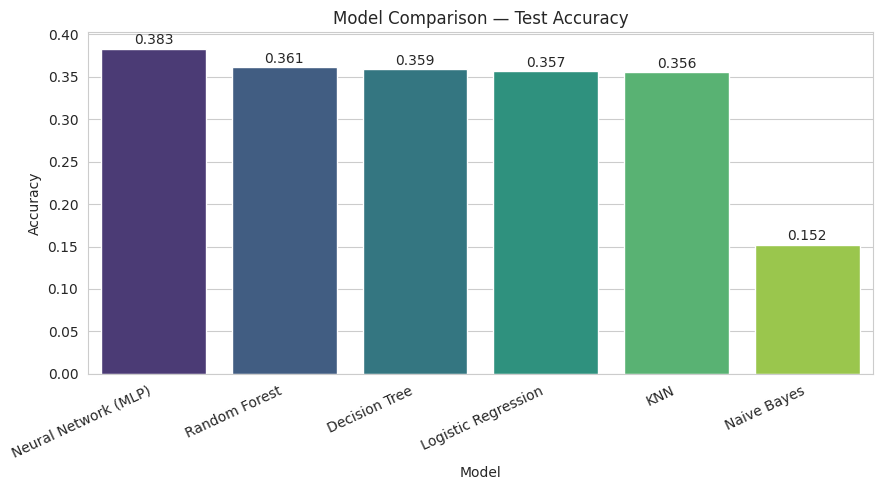

In [81]:
plt.figure(figsize=(9, 5))
order = results_df.sort_values('Accuracy', ascending=False)
sns.barplot(data=order, x='Model', y='Accuracy', hue='Model', palette='viridis', legend=False)
plt.title('Model Comparison — Test Accuracy')
plt.ylabel('Accuracy')
plt.xticks(rotation=25, ha='right')
for i, v in enumerate(order['Accuracy']):
    plt.text(i, v + 0.005, f'{v:.3f}', ha='center')
plt.tight_layout()
plt.savefig('outputs_model_comparison_accuracy.png', dpi=110)
plt.show()

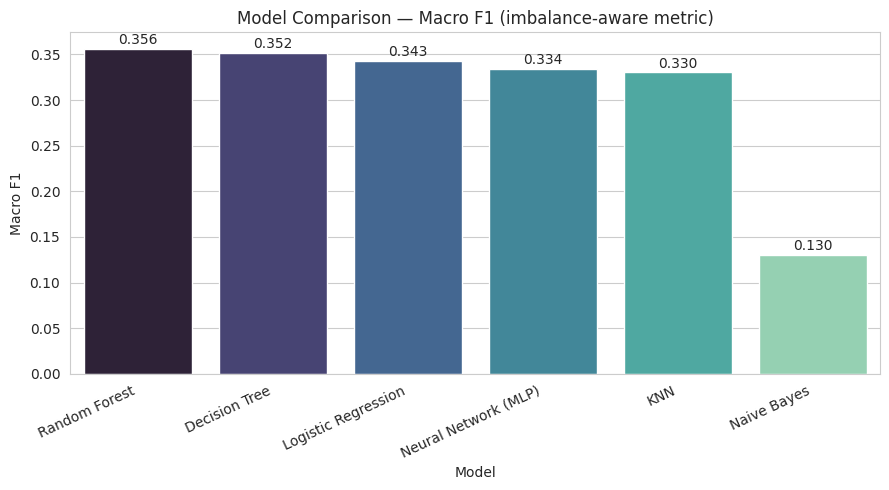

In [82]:
plt.figure(figsize=(9, 5))
order2 = results_df.sort_values('Macro F1', ascending=False)
sns.barplot(data=order2, x='Model', y='Macro F1', hue='Model', palette='mako', legend=False)
plt.title('Model Comparison — Macro F1 (imbalance-aware metric)')
plt.ylabel('Macro F1')
plt.xticks(rotation=25, ha='right')
for i, v in enumerate(order2['Macro F1']):
    plt.text(i, v + 0.005, f'{v:.3f}', ha='center')
plt.tight_layout()
plt.savefig('outputs_model_comparison_macrof1.png', dpi=110)
plt.show()

**Interpretation of the comparison (based on the actual numbers above, not assumed):**

All six models score similarly (0.33–0.39 accuracy), showing the available features only weakly predict player role — barely better than just guessing the majority class. Naive Bayes performs worst, since its independence assumption is violated by the correlated missing-value patterns in batting/bowling style. Random Forest and Decision Tree do slightly better on Macro F1 because trees can capture feature interactions that linear/distance-based models can't. Class imbalance hurts every model, with Wicketkeeper (the smallest class) recalled worst everywhere — which is why macro metrics are consistently lower than weighted ones

### 12. Cross-Validation


In [83]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = []
for name, clf in models.items():
    pipe = Pipeline([('prep', preprocessor), ('clf', clf)])
    scores = cross_val_score(pipe, X_train, y_train, cv=skf, scoring='f1_macro', n_jobs=-1)
    cv_results.append({'Model': name, 'CV Macro F1 Mean': scores.mean(), 'CV Macro F1 Std': scores.std()})
    print(f"{name:22s} mean Macro F1 = {scores.mean():.4f}  (std = {scores.std():.4f})  "
          f"folds = {np.round(scores, 3)}")

cv_df = pd.DataFrame(cv_results).sort_values('CV Macro F1 Mean', ascending=False)
cv_df

Logistic Regression    mean Macro F1 = 0.3391  (std = 0.0117)  folds = [0.333 0.328 0.339 0.334 0.361]
KNN                    mean Macro F1 = 0.3250  (std = 0.0120)  folds = [0.303 0.332 0.322 0.332 0.336]
Decision Tree          mean Macro F1 = 0.3437  (std = 0.0032)  folds = [0.338 0.344 0.347 0.347 0.343]
Naive Bayes            mean Macro F1 = 0.1356  (std = 0.0025)  folds = [0.14  0.135 0.136 0.133 0.134]
Neural Network (MLP)   mean Macro F1 = 0.3270  (std = 0.0204)  folds = [0.322 0.349 0.324 0.293 0.347]
Random Forest          mean Macro F1 = 0.3512  (std = 0.0065)  folds = [0.346 0.347 0.354 0.346 0.363]


,Model,CV Macro F1 Mean,CV Macro F1 Std
5,Random Forest,0.351162,0.006538
2,Decision Tree,0.343695,0.003242
0,Logistic Regression,0.339110,0.011673
4,Neural Network (MLP),0.326964,0.020439
1,KNN,0.325042,0.011968
3,Naive Bayes,0.135628,0.002459


## 13. K-Means Clustering (Unsupervised Learning)


In [84]:
X_full = pd.concat([X_train, X_test])
y_full = pd.concat([y_train, y_test])

kmeans_preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_FEATURES),
    ('num', StandardScaler(), NUM_FEATURES),
    ('flag', 'passthrough', FLAG_FEATURES),
])
X_full_transformed = kmeans_preprocessor.fit_transform(X_full)
print("Transformed feature matrix shape:", X_full_transformed.shape)

Transformed feature matrix shape: (17385, 24)


### Choosing the number of clusters (elbow + silhouette)

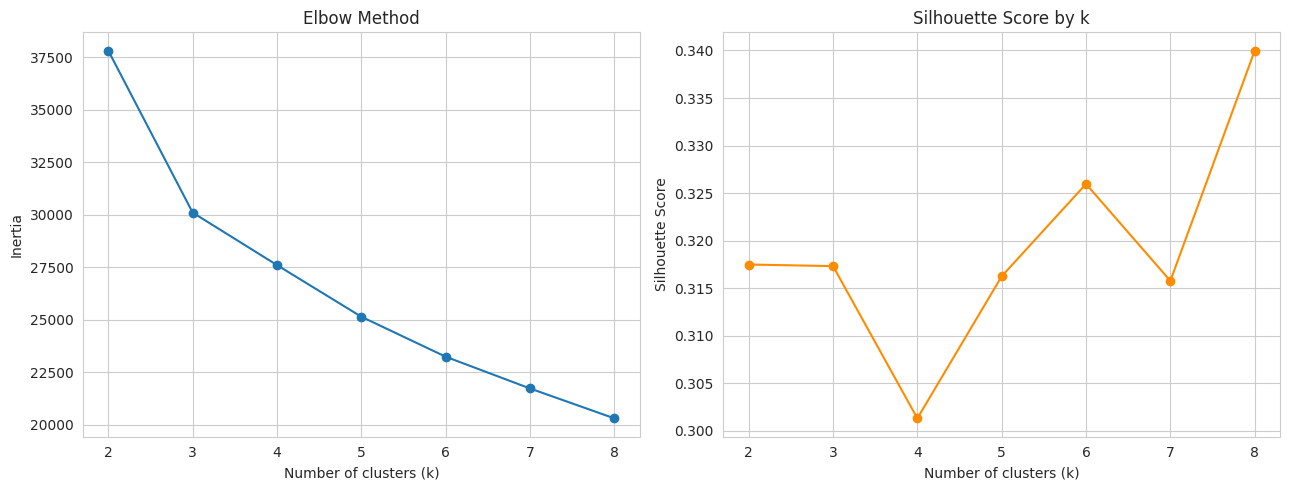

k=2: inertia=37803.2, silhouette=0.3175
k=3: inertia=30102.5, silhouette=0.3173
k=4: inertia=27605.4, silhouette=0.3013
k=5: inertia=25148.7, silhouette=0.3162
k=6: inertia=23247.4, silhouette=0.3260
k=7: inertia=21736.6, silhouette=0.3158
k=8: inertia=20315.1, silhouette=0.3400


In [85]:
K_range = range(2, 9)
inertias, sil_scores = [], []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_k = km.fit_predict(X_full_transformed)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_full_transformed, labels_k, sample_size=3000, random_state=RANDOM_STATE)
    sil_scores.append(sil)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(list(K_range), inertias, marker='o')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')

axes[1].plot(list(K_range), sil_scores, marker='o', color='darkorange')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by k')
plt.tight_layout()
plt.savefig('outputs_kmeans_k_selection.png', dpi=110)
plt.show()

for k, inertia, sil in zip(K_range, inertias, sil_scores):
    print(f"k={k}: inertia={inertia:.1f}, silhouette={sil:.4f}")

In [86]:
kmeans_final = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_full_transformed)

### PCA 2D visualization of the clusters

Variance explained by 2 PCA components: 60.43%


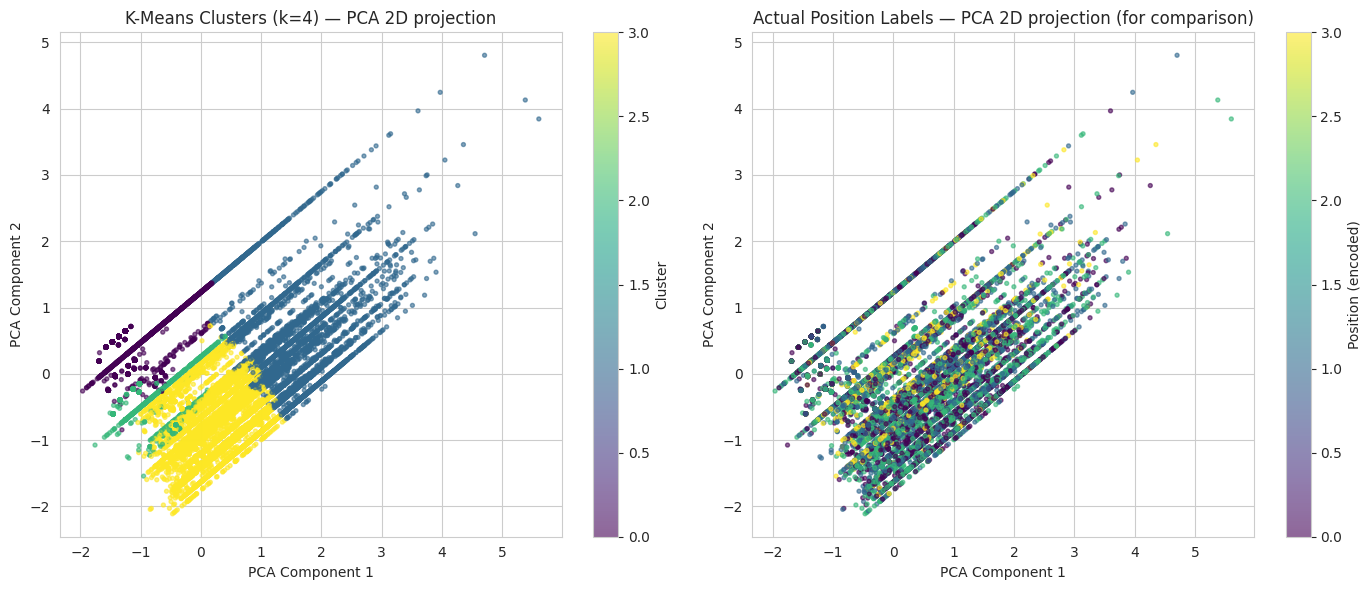

In [87]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_full_transformed)
print(f"Variance explained by 2 PCA components: {pca.explained_variance_ratio_.sum():.2%}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', s=8, alpha=0.6)
axes[0].set_title('K-Means Clusters (k=4) — PCA 2D projection')
axes[0].set_xlabel('PCA Component 1')
axes[0].set_ylabel('PCA Component 2')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

y_full_codes = y_full.astype('category').cat.codes
scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y_full_codes, cmap='viridis', s=8, alpha=0.6)
axes[1].set_title('Actual Position Labels — PCA 2D projection (for comparison)')
axes[1].set_xlabel('PCA Component 1')
axes[1].set_ylabel('PCA Component 2')
plt.colorbar(scatter2, ax=axes[1], label='Position (encoded)')

plt.tight_layout()
plt.savefig('outputs_kmeans_pca.png', dpi=110)
plt.show()

### Clusters vs. actual position labels

In [88]:
crosstab = pd.crosstab(cluster_labels, y_full.values, rownames=['Cluster'], colnames=['Actual Position'])
crosstab_pct = crosstab.div(crosstab.sum(axis=1), axis=0)
print("Counts:")
print(crosstab)
print("\nRow-normalized proportions:")
print(crosstab_pct.round(2))

Counts:
Actual Position  Allrounder  Batsman  Bowler  Wicketkeeper
Cluster                                                   
0                      1582     1534    1711           440
1                      1133     1229    1242           459
2                       504      647     649           216
3                      1745     1608    2109           577

Row-normalized proportions:
Actual Position  Allrounder  Batsman  Bowler  Wicketkeeper
Cluster                                                   
0                      0.30     0.29    0.32          0.08
1                      0.28     0.30    0.31          0.11
2                      0.25     0.32    0.32          0.11
3                      0.29     0.27    0.35          0.10


**Discussion:** the crosstab shows that each K-Means cluster contains a fairly similar mix of all 4
position labels, rather than each cluster being dominated by one role. In other words, **K-Means
does not spontaneously rediscover the position categories from these features alone**

## 15. Final Findings

In [89]:
print("Best model by test Macro F1:")
print(results_df.iloc[0][['Model', 'Accuracy', 'Macro F1', 'ROC-AUC (macro OvR)']])
print("\nWorst model by test Macro F1:")
print(results_df.iloc[-1][['Model', 'Accuracy', 'Macro F1', 'ROC-AUC (macro OvR)']])

Best model by test Macro F1:
Model                  Random Forest
Accuracy                    0.361231
Macro F1                    0.356324
ROC-AUC (macro OvR)         0.641342
Name: 0, dtype: object

Worst model by test Macro F1:
Model                  Naive Bayes
Accuracy                  0.152143
Macro F1                  0.130338
ROC-AUC (macro OvR)       0.605974
Name: 5, dtype: object


In [90]:
best_model_name = results_df.iloc[0]['Model']
best_macro_f1 = results_df.iloc[0]['Macro F1']
worst_model_name = results_df.iloc[-1]['Model']
worst_macro_f1 = results_df.iloc[-1]['Macro F1']
print(f"Best model on test Macro F1:  {best_model_name} ({best_macro_f1:.4f})")
print(f"Worst model on test Macro F1: {worst_model_name} ({worst_macro_f1:.4f})")

Best model on test Macro F1:  Random Forest (0.3563)
Worst model on test Macro F1: Naive Bayes (0.1303)


## 16. Conclusion

Predicting a cricket player's on-field role from batting
style, bowling style, continent, gender, and age is a **genuinely hard classification problem** with
this feature set — all 6 models land in a modest, narrow performance band (roughly 33–39% test
accuracy, 0.13–0.36 macro F1), with the printed "best model" above performing best on Macro F1 and
Naive Bayes performing clearly worst due to its violated independence assumption.

The features most directly tied to cricket skill
(batting/bowling style) only partially and indirectly encode role (an allrounder and a specialist
bowler can share the exact same bowling style value), while continent, gender, and age carry very
little role-specific signal on their own, as the EDA showed. The class imbalance (`Wicketkeeper`
being the smallest class) further limits how well any model can learn that category specifically.

**Main challenges faced:**
- Two separate, genuinely deceptive data-quality issues in `dateofbirth` (a database sentinel value
  and a statistically-confirmed placeholder-date pattern affecting over a third of the dataset)
  that required real investigation, not assumption, before the `age` feature could be trusted.
- Missingness in `battingstyle`/`bowlingstyle` that is informative but also partly a
  data-collection artifact, creating a mild, unavoidable leakage-adjacent limitation that we chose
  to document rather than hide.
- A modest ceiling on achievable accuracy given the available features — a reminder that not every
  real-world dataset supports a highly accurate classifier, and that honestly reporting a "hard"
  problem is more valuable than manufacturing an artificially clean result.